# Quantara — Full ML Pipeline
### Band Gap Prediction for Oxide Materials

This notebook covers the complete machine learning pipeline for the Quantara materials intelligence platform:

1. **Data Loading & Overview**
2. **Exploratory Data Analysis (EDA)**
3. **Data Preprocessing & Feature Engineering**
4. **Model Training & Comparison** (Random Forest, Gradient Boosting, XGBoost)
5. **Model Evaluation & Metrics**
6. **SHAP Explainability**
7. **Confidence Intervals (Quantile Regression)**
8. **PCA — Materials Property Space**

---
## 0. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import shap
import os

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.decomposition import PCA

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed — run: pip install xgboost')

warnings.filterwarnings('ignore')
shap.initjs()

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0a0a0a',
    'axes.facecolor':   '#0f0f0f',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'text.color':       '#cccccc',
    'grid.color':       '#222222',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
BLUE   = '#0071e3'
GREEN  = '#34d399'
AMBER  = '#f59e0b'
RED    = '#ef4444'
PURPLE = '#a78bfa'

print('All imports successful.')

All imports successful.


---
## 1. Data Loading & Overview

The dataset is stored as a compressed NumPy archive (`dataset.npz`) containing:
- `X` — feature matrix (11 structural/chemical features per material)
- `y_reg` — regression target (band gap in eV)
- `y_clf` — classification target (1 = metallic, 0 = non-metallic)
- `formulas` — chemical formula strings

In [3]:
# ── Load dataset ─────────────────────────────────────────────
DATA_PATH  = '../data/processed/dataset.npz'
MODEL_PATH = '../models/trained_model.pkl'

data     = np.load(DATA_PATH, allow_pickle=True)
X        = data['X'].astype(float)
y_reg    = data['y_reg'].astype(float)
y_clf    = data['y_clf'].astype(int)
formulas = data['formulas'] if 'formulas' in data else np.array([f'M{i}' for i in range(len(X))])

FEATURE_NAMES = [
    'Bond Length (avg)', 'Bond Length (std)', 'Bond Angle (avg)',
    'Angle Std',         'Min Angle',         'Max Angle',
    'Coordination',      'Atomic Number',     'Electronegativity',
    'Oxidation State',   'Volume / Atom'
]

df = pd.DataFrame(X, columns=FEATURE_NAMES)
df['band_gap']    = y_reg
df['is_metallic'] = y_clf
df['formula']     = formulas
df['material_type'] = df.apply(
    lambda r: 'Metal' if r.is_metallic else ('Semiconductor' if r.band_gap < 3.0 else 'Insulator'), axis=1
)

print(f'Dataset shape : {X.shape}')
print(f'Samples       : {len(X):,}')
print(f'Features      : {X.shape[1]}')
print(f'Band gap range: {y_reg.min():.3f} – {y_reg.max():.3f} eV')
print(f'Metallic      : {y_clf.sum():,} ({y_clf.mean()*100:.1f}%)')
print(f'Non-metallic  : {(1-y_clf).sum():,} ({(1-y_clf).mean()*100:.1f}%)')
df.head()

Dataset shape : (7994, 11)
Samples       : 7,994
Features      : 11
Band gap range: 0.000 – 8.375 eV
Metallic      : 3,246 (40.6%)
Non-metallic  : 4,748 (59.4%)


,Bond Length (avg),Bond Length (std),Bond Angle (avg),Angle Std,Min Angle,Max Angle,Coordination,Atomic Number,Electronegativity,Oxidation State,Volume / Atom,band_gap,is_metallic,formula,material_type
0,2.710466,0.202088,104.708825,25.535323,67.371453,171.073594,4.56,56.0,0.89,2.0,25.687758,1.7049,0,M0,Semiconductor
1,2.024921,0.145500,109.351298,23.853410,67.153206,172.257663,3.90,27.0,1.88,2.0,13.052950,0.2197,0,M1,Semiconductor
2,2.381279,0.164464,105.548223,26.701869,64.336373,175.161125,4.84,20.0,1.00,2.0,16.567854,2.1384,0,M2,Semiconductor
3,1.658013,0.102023,110.447466,12.178951,73.369778,150.898793,3.76,4.0,1.57,2.0,8.030707,4.4843,0,M3,Insulator
4,1.652631,0.095401,110.430996,12.226473,77.877210,143.744867,3.74,4.0,1.57,2.0,8.266267,4.4524,0,M4,Insulator


In [4]:
# ── Basic statistics ─────────────────────────────────────────
df[FEATURE_NAMES + ['band_gap']].describe().round(3)

,Bond Length (avg),Bond Length (std),Bond Angle (avg),Angle Std,Min Angle,Max Angle,Coordination,Atomic Number,Electronegativity,Oxidation State,Volume / Atom,band_gap
count,7994.000,7994.000,7994.000,7994.000,7994.000,7994.000,7994.000,7994.000,7992.000,7994.000,7994.000,7994.000
mean,2.134,0.177,101.763,24.943,75.738,151.637,5.056,31.601,1.894,1.782,15.212,1.372
std,0.393,0.182,33.050,14.281,33.236,48.912,2.029,19.097,0.643,1.380,8.512,1.676
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.790,0.000,6.053,0.000
25%,1.942,0.023,100.000,17.701,60.000,142.707,4.000,15.857,1.430,0.500,11.512,0.000
50%,2.124,0.109,105.977,30.820,76.071,176.429,4.750,26.000,1.775,2.000,13.385,0.695
75%,2.377,0.333,109.471,36.288,86.130,180.000,6.000,43.500,2.185,3.000,16.942,2.253
max,3.407,1.066,180.000,64.690,180.000,180.000,12.000,94.000,3.980,6.000,442.600,8.375


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Band Gap Distribution
Understanding the target variable distribution is critical. Oxide materials span from metals (0 eV) through semiconductors (~0.5–3 eV) to wide-gap insulators (>3 eV).

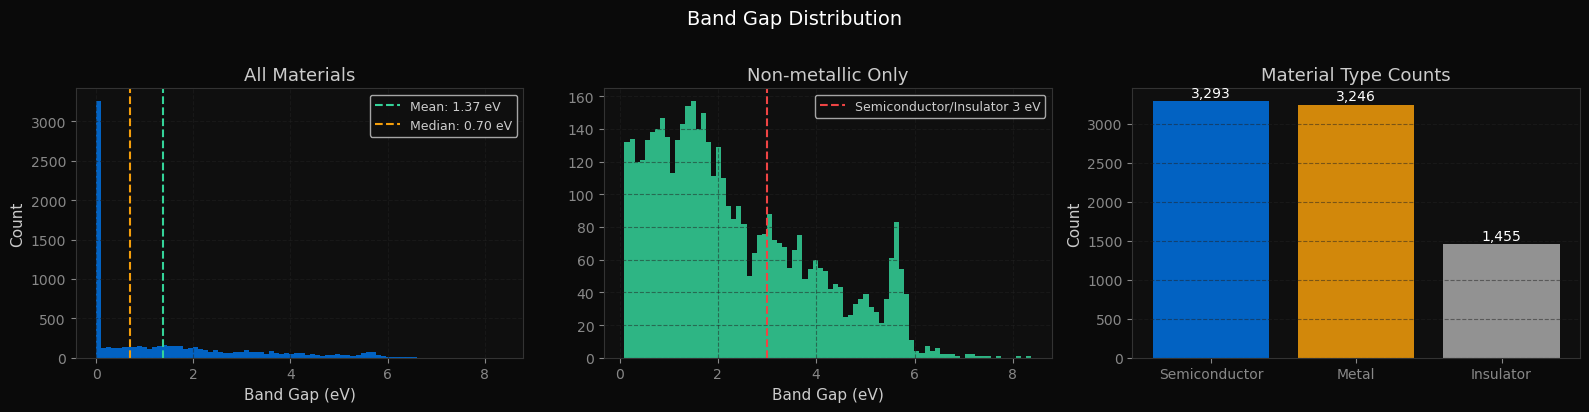

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Band Gap Distribution', fontsize=14, color='white', y=1.02)

# All materials
axes[0].hist(y_reg, bins=80, color=BLUE, alpha=0.85, edgecolor='none')
axes[0].set_title('All Materials')
axes[0].set_xlabel('Band Gap (eV)')
axes[0].set_ylabel('Count')
axes[0].axvline(y_reg.mean(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mean: {y_reg.mean():.2f} eV')
axes[0].axvline(np.median(y_reg), color=AMBER, linestyle='--', linewidth=1.5, label=f'Median: {np.median(y_reg):.2f} eV')
axes[0].legend(fontsize=9)
axes[0].grid(True)

# Non-metallic only
nm_gaps = y_reg[y_clf == 0]
axes[1].hist(nm_gaps, bins=80, color=GREEN, alpha=0.85, edgecolor='none')
axes[1].set_title('Non-metallic Only')
axes[1].set_xlabel('Band Gap (eV)')
axes[1].axvline(3.0, color=RED, linestyle='--', linewidth=1.5, label='Semiconductor/Insulator 3 eV')
axes[1].legend(fontsize=9)
axes[1].grid(True)

# Material type counts
type_counts = df['material_type'].value_counts()
colors_bar  = [AMBER, BLUE, '#aaaaaa']
bars = axes[2].bar(type_counts.index, type_counts.values,
                   color=[AMBER if t=='Metal' else BLUE if t=='Semiconductor' else '#aaaaaa'
                          for t in type_counts.index], alpha=0.85)
axes[2].set_title('Material Type Counts')
axes[2].set_ylabel('Count')
for bar, val in zip(bars, type_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, color='white')
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_band_gap_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 2.2 Feature Distributions

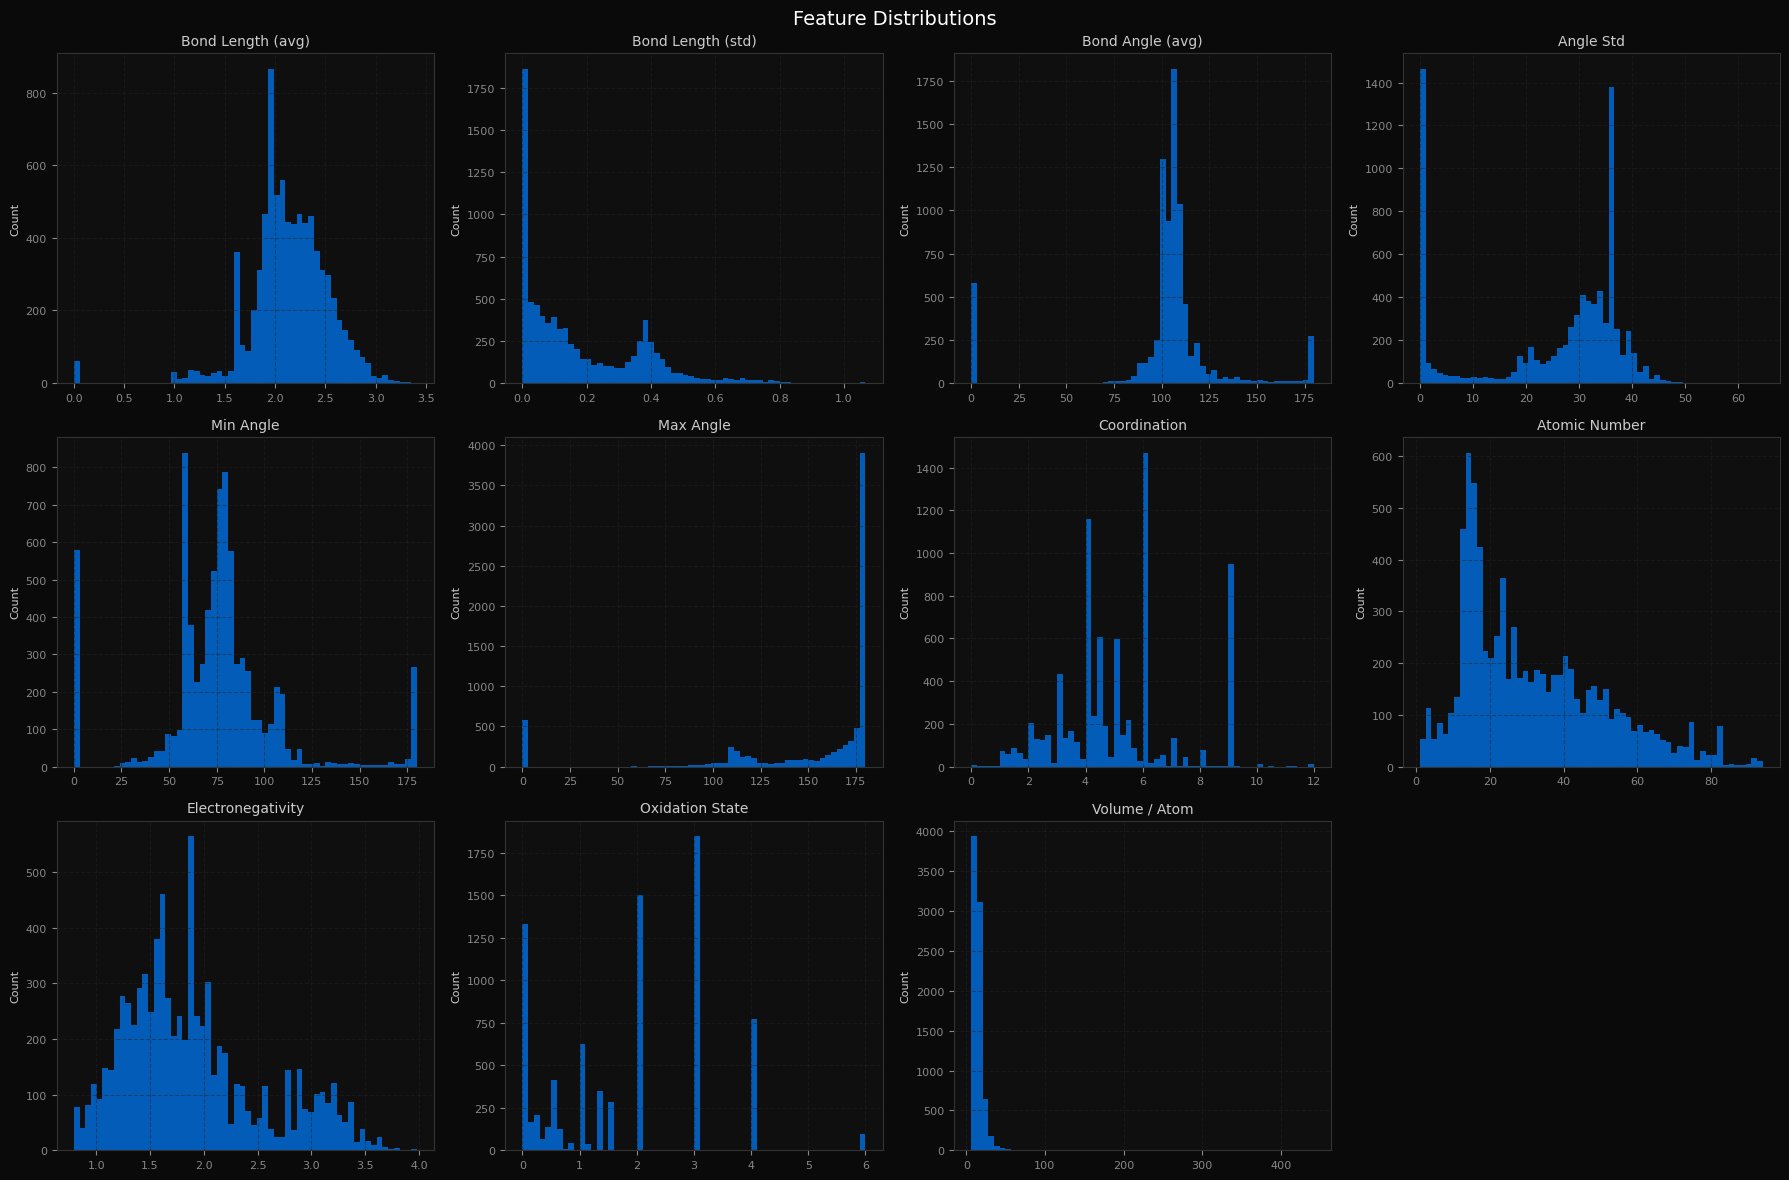

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Feature Distributions', fontsize=14, color='white')
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    vals = df[feat].dropna()
    axes[i].hist(vals, bins=60, color=BLUE, alpha=0.8, edgecolor='none')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].grid(True)
    axes[i].tick_params(labelsize=8)

# Hide unused subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 2.3 Correlation Heatmap
Shows linear correlations between all features and the target. High correlation between features suggests possible redundancy.

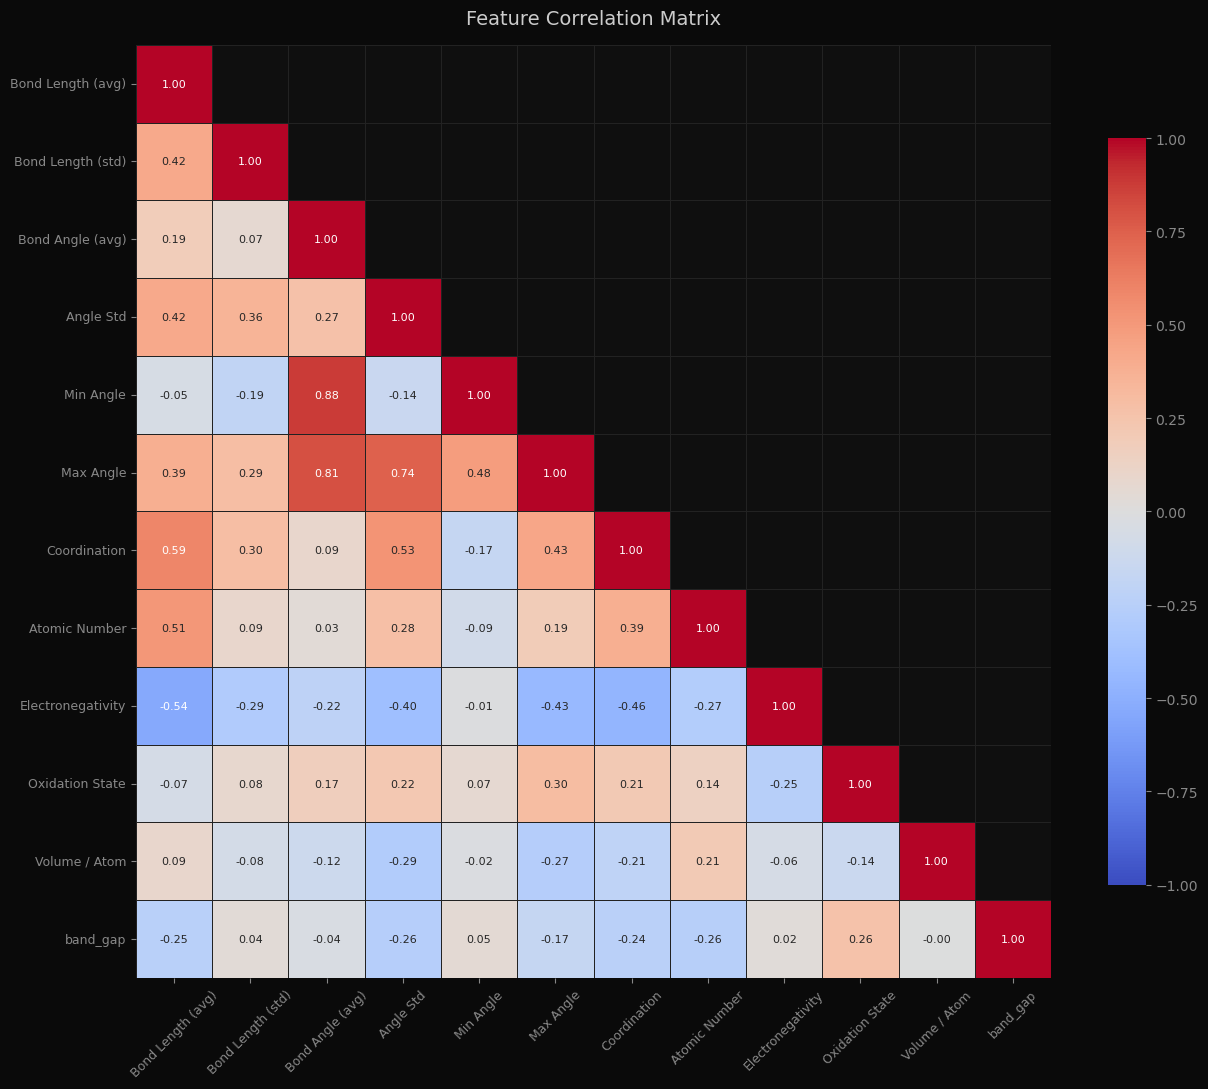


Top feature correlations with band_gap:
Angle Std           -0.263
Oxidation State      0.258
Atomic Number       -0.256
Bond Length (avg)   -0.247
Coordination        -0.236
Max Angle           -0.169
Min Angle            0.054
Bond Length (std)    0.038
Bond Angle (avg)    -0.037
Electronegativity    0.024
Volume / Atom       -0.002


In [7]:
corr_df = df[FEATURE_NAMES + ['band_gap']].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#222222',
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# Print top correlations with band_gap
print('\nTop feature correlations with band_gap:')
print(corr_df['band_gap'].drop('band_gap').sort_values(key=abs, ascending=False).round(3).to_string())

### 2.4 Feature vs Band Gap Scatter Plots

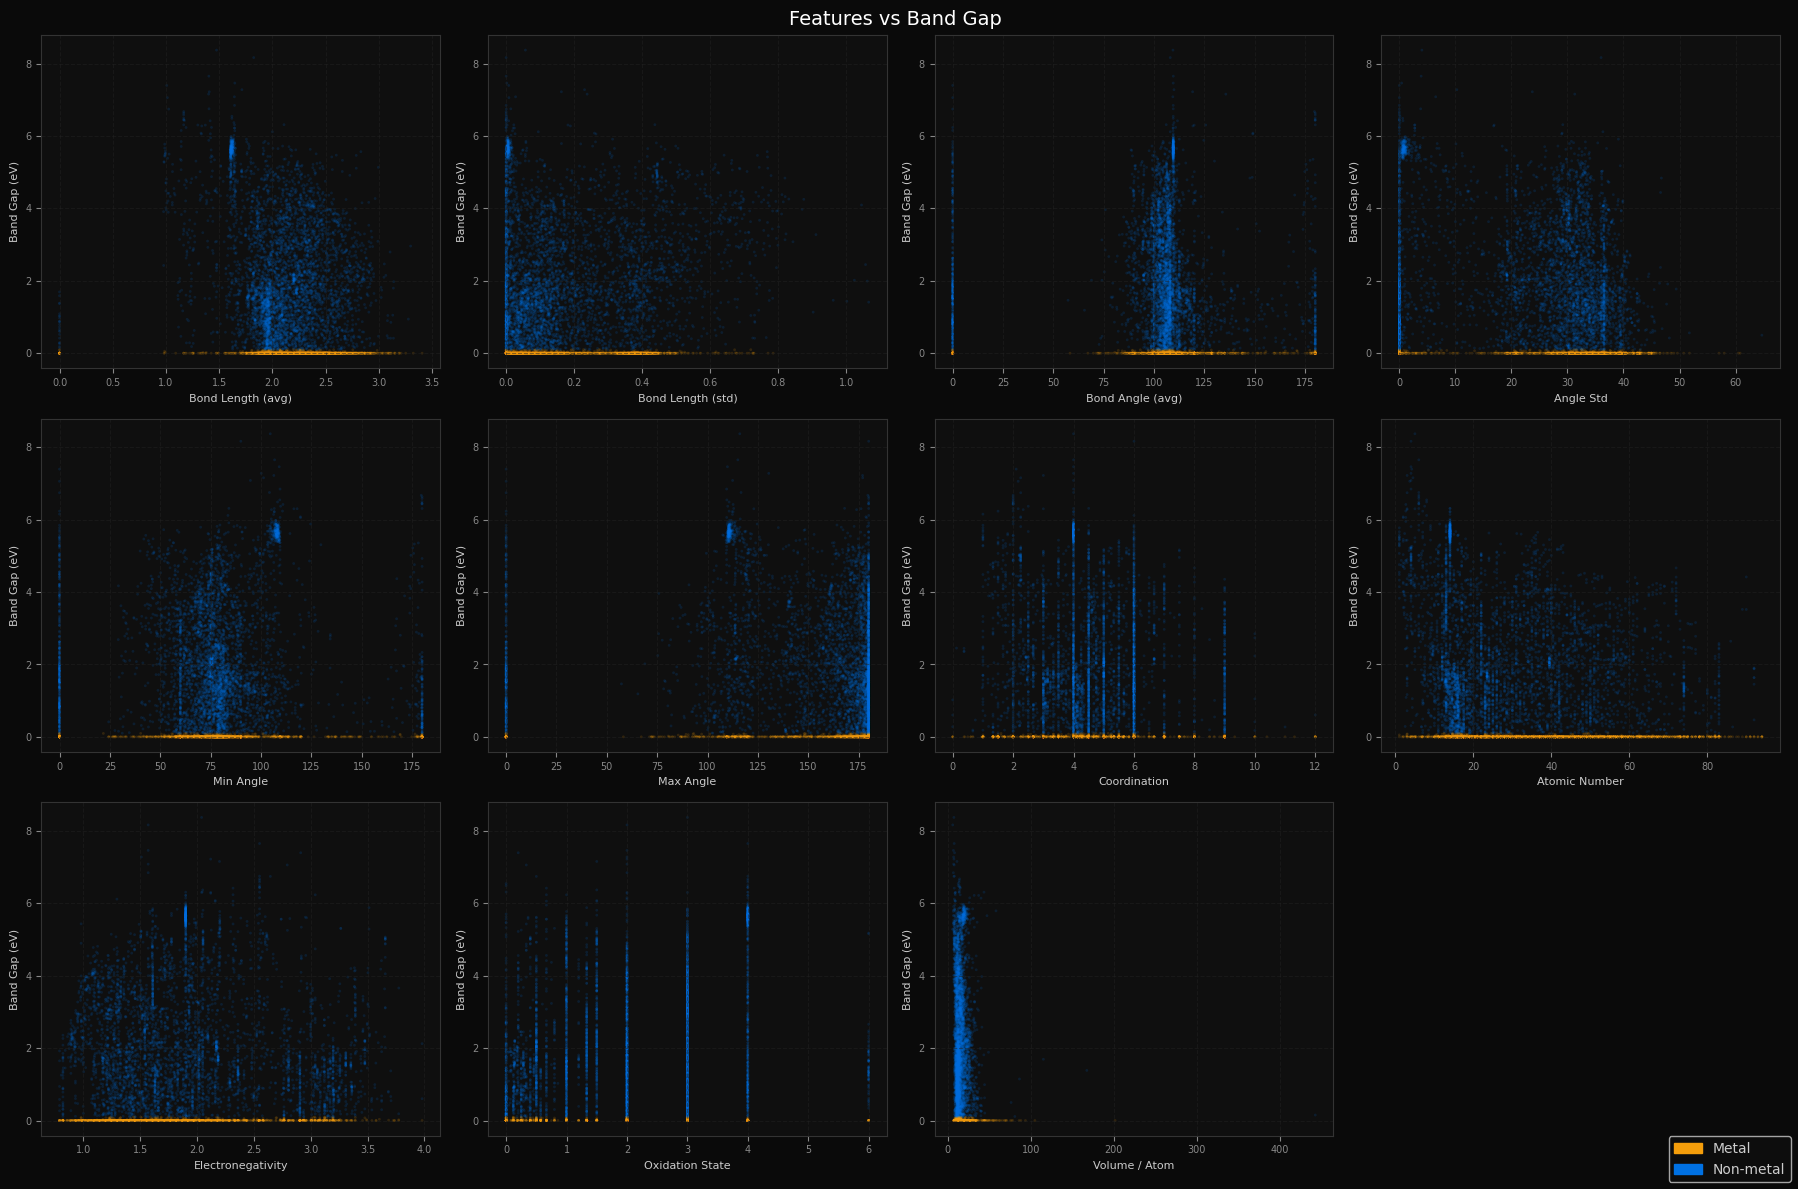

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Features vs Band Gap', fontsize=14, color='white')
axes = axes.flatten()

colors = [AMBER if m else BLUE for m in y_clf]

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.scatter(df[feat], df['band_gap'], c=colors, alpha=0.15, s=4, edgecolors='none')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('Band Gap (eV)', fontsize=8)
    ax.grid(True)
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
metal_patch = mpatches.Patch(color=AMBER, label='Metal')
nmet_patch  = mpatches.Patch(color=BLUE,  label='Non-metal')
fig.legend(handles=[metal_patch, nmet_patch], loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('eda_scatter_plots.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 2.5 Missing Value Analysis

                   Missing Count  Missing %
Bond Length (avg)              0       0.00
Bond Length (std)              0       0.00
Bond Angle (avg)               0       0.00
Angle Std                      0       0.00
Min Angle                      0       0.00
Max Angle                      0       0.00
Coordination                   0       0.00
Atomic Number                  0       0.00
Electronegativity              2       0.03
Oxidation State                0       0.00
Volume / Atom                  0       0.00


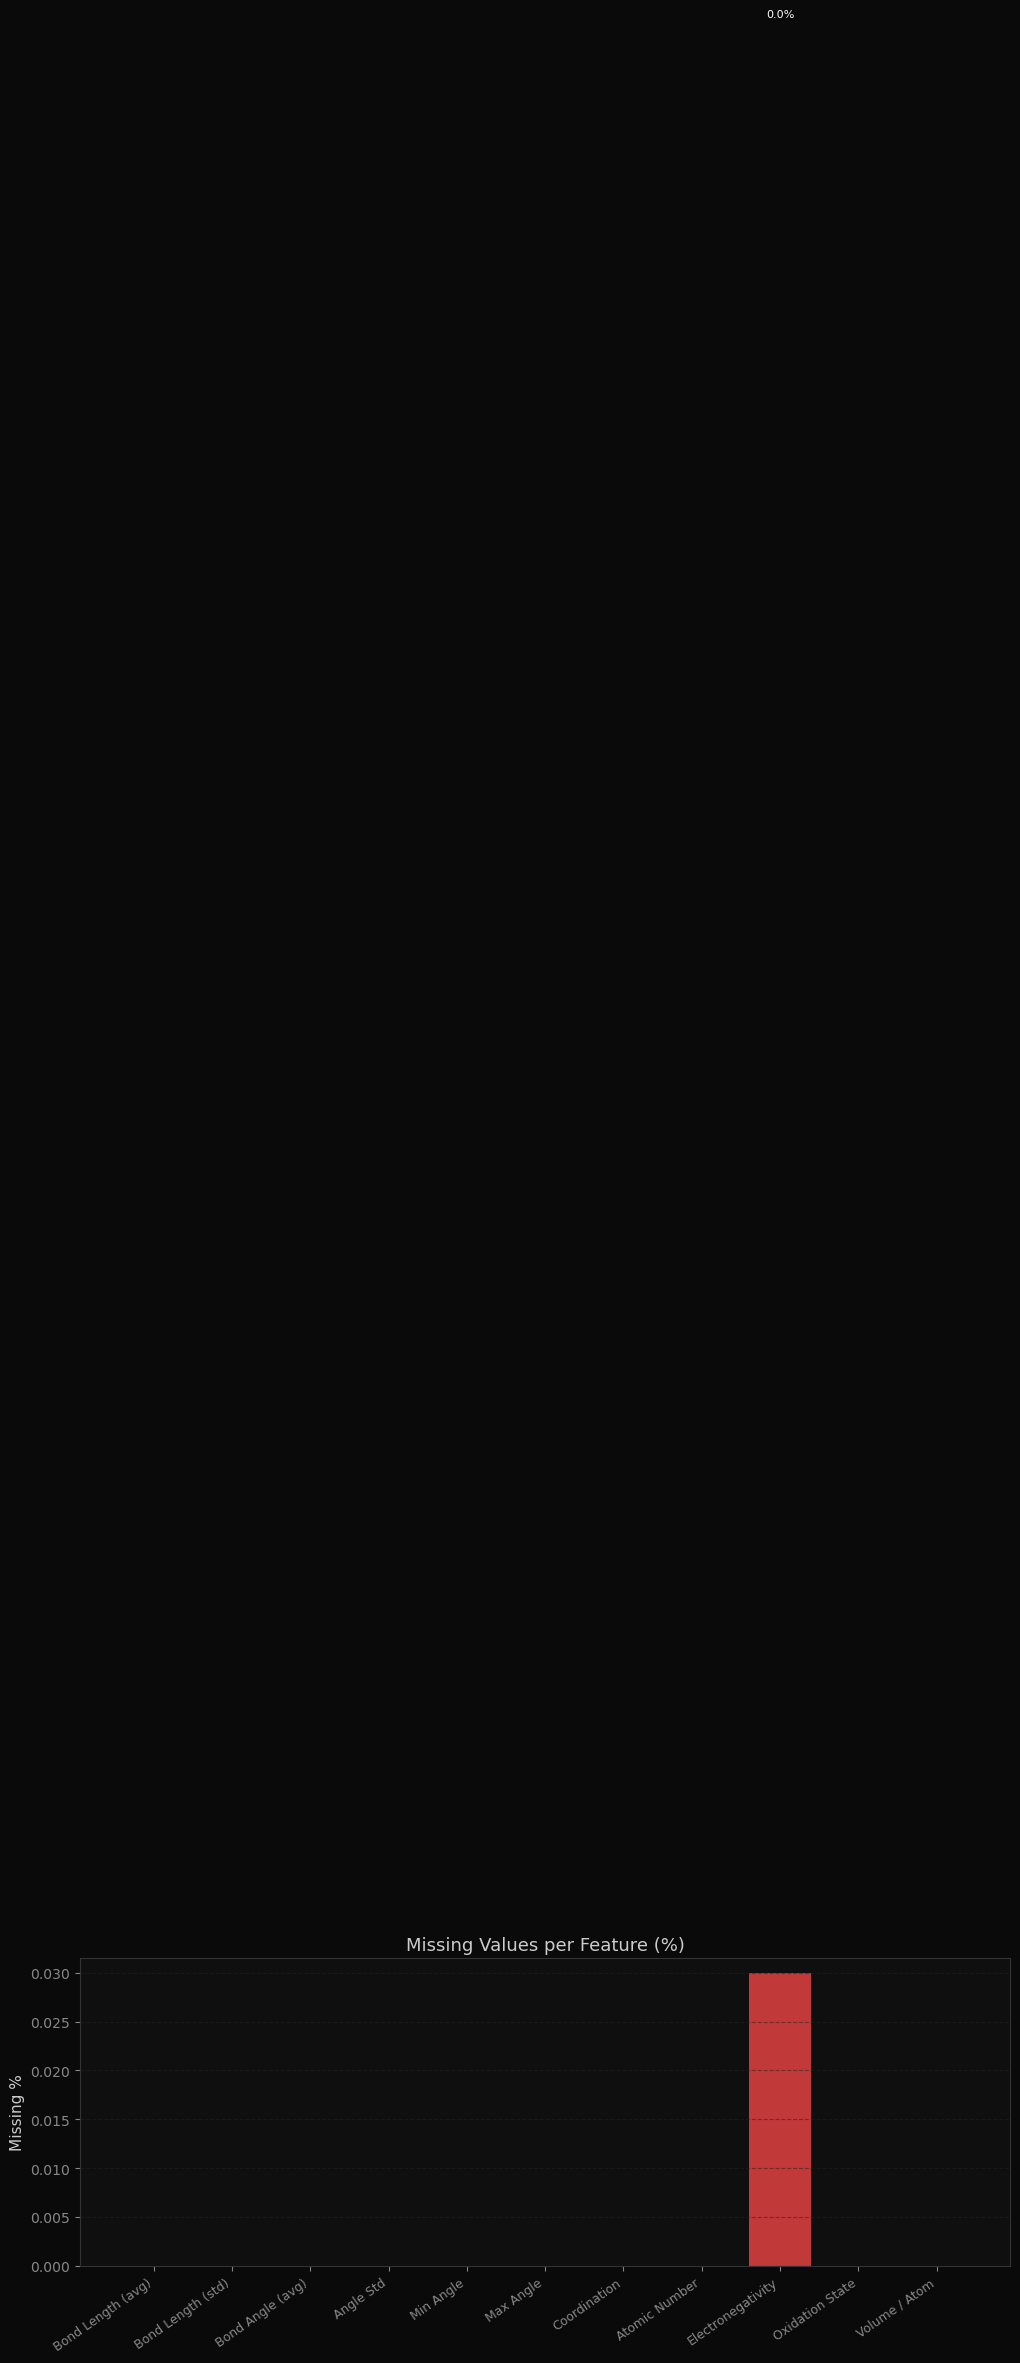

In [9]:
missing = df[FEATURE_NAMES].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(FEATURE_NAMES, missing_pct.values, color=RED, alpha=0.8)
ax.set_title('Missing Values per Feature (%)', fontsize=13)
ax.set_ylabel('Missing %')
ax.set_xticklabels(FEATURE_NAMES, rotation=35, ha='right', fontsize=9)
ax.grid(True, axis='y')
for bar, val in zip(bars, missing_pct.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 2.6 Band Gap by Material Type (Box Plot)

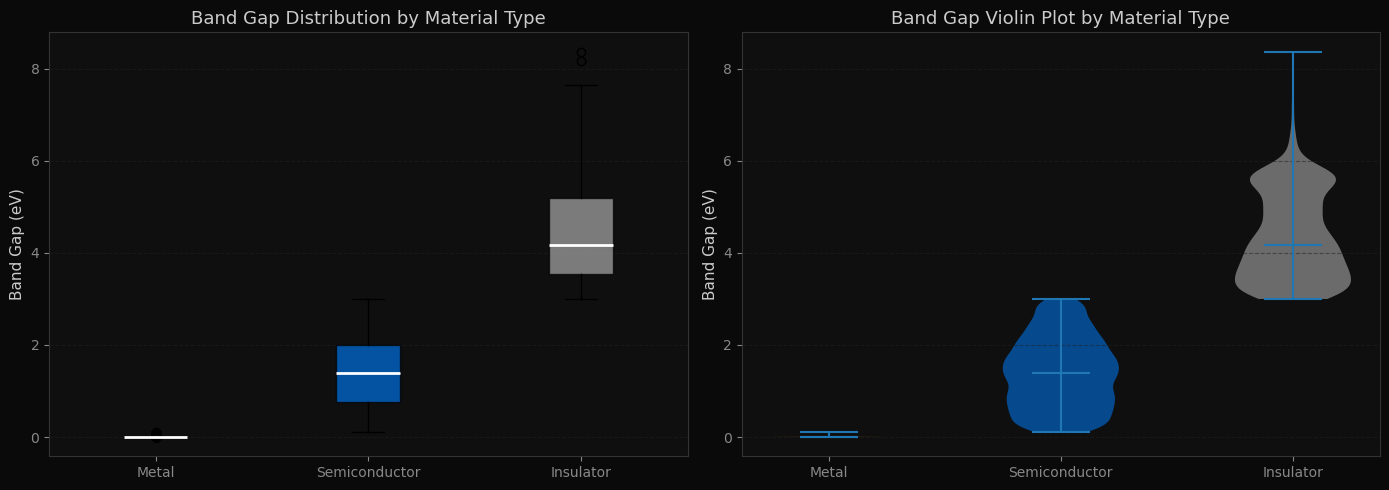

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_order  = ['Metal', 'Semiconductor', 'Insulator']
type_colors = [AMBER, BLUE, '#aaaaaa']
type_data   = [df[df.material_type == t]['band_gap'].values for t in type_order]

bp = axes[0].boxplot(type_data, labels=type_order, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], type_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Band Gap Distribution by Material Type')
axes[0].set_ylabel('Band Gap (eV)')
axes[0].grid(True, axis='y')

# Violin plot
parts = axes[1].violinplot(type_data, positions=[1, 2, 3], showmedians=True)
for pc, color in zip(parts['bodies'], type_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(type_order)
axes[1].set_title('Band Gap Violin Plot by Material Type')
axes[1].set_ylabel('Band Gap (eV)')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

---
## 3. Data Preprocessing & Feature Engineering

### 3.1 Train/Test Split

In [11]:
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print(f'Train size : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test size  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'Train band gap range: {y_train_reg.min():.3f} – {y_train_reg.max():.3f} eV')
print(f'Test  band gap range: {y_test_reg.min():.3f} – {y_test_reg.max():.3f} eV')

Train size : 6,395 (80%)
Test size  : 1,599  (20%)
Train band gap range: 0.000 – 8.375 eV
Test  band gap range: 0.000 – 7.464 eV


### 3.2 Imputation
Some structural features (e.g. bond angles) are undefined for certain structures. We impute missing values with the column mean.

In [12]:
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

print('NaNs before imputation:', np.isnan(X_train).sum())
print('NaNs after imputation :', np.isnan(X_train_imp).sum())

NaNs before imputation: 2
NaNs after imputation : 0


### 3.3 Feature Importance (Variance)
Check which features have meaningful variance and are not near-constant.

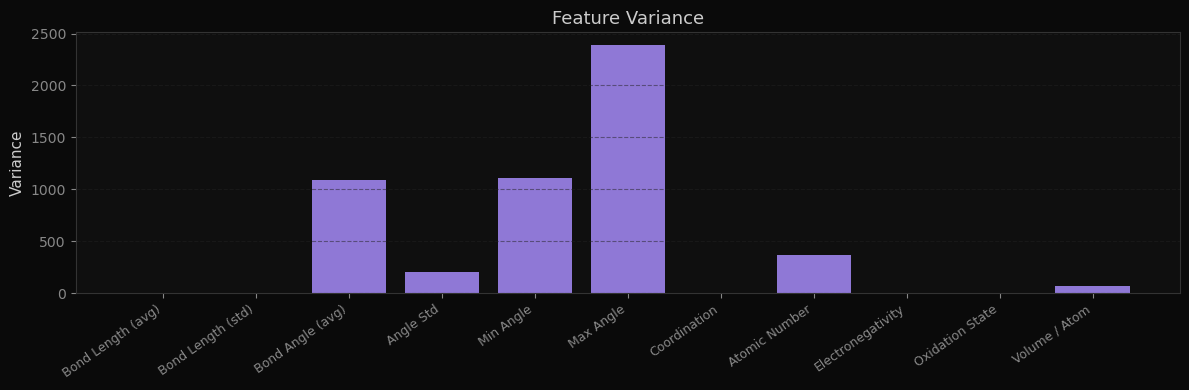

          Feature  Variance
        Max Angle 2392.1040
        Min Angle 1104.5262
 Bond Angle (avg) 1092.1351
    Atomic Number  364.6627
        Angle Std  203.9294
    Volume / Atom   72.4476
     Coordination    4.1171
  Oxidation State    1.9049
Electronegativity    0.4132
Bond Length (avg)    0.1542
Bond Length (std)    0.0330


In [13]:
variances = np.nanvar(X, axis=0)
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(FEATURE_NAMES, variances, color=PURPLE, alpha=0.85)
ax.set_title('Feature Variance', fontsize=13)
ax.set_ylabel('Variance')
ax.set_xticklabels(FEATURE_NAMES, rotation=35, ha='right', fontsize=9)
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('preprocessing_variance.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

variance_df = pd.DataFrame({'Feature': FEATURE_NAMES, 'Variance': variances.round(4)})
print(variance_df.sort_values('Variance', ascending=False).to_string(index=False))

---
## 4. Model Training & Comparison

We train and compare three models for **regression** (band gap prediction) and **classification** (metallic vs non-metallic):
- Random Forest
- Gradient Boosting
- XGBoost

### 4.1 Regression Models

In [14]:
reg_models = {
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                               max_depth=4, random_state=42))
    ]),
}

if XGB_AVAILABLE:
    reg_models['XGBoost'] = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                      max_depth=4, random_state=42,
                                      verbosity=0, n_jobs=-1))
    ])

reg_results = {}
for name, model in reg_models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae  = mean_absolute_error(y_test_reg, y_pred)
    r2   = r2_score(y_test_reg, y_pred)
    reg_results[name] = {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4), 'predictions': y_pred}
    print(f'  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

print('\nDone.')

Training Random Forest...
  RMSE=0.8487  MAE=0.5651  R²=0.7396
Training Gradient Boosting...
  RMSE=0.9840  MAE=0.7303  R²=0.6499
Training XGBoost...
  RMSE=0.9857  MAE=0.7301  R²=0.6487

Done.


### 4.2 Classification Models

In [15]:
clf_models = {
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                max_depth=4, random_state=42))
    ]),
}

if XGB_AVAILABLE:
    clf_models['XGBoost'] = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model',   xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, random_state=42,
                                       verbosity=0, n_jobs=-1,
                                       use_label_encoder=False, eval_metric='logloss'))
    ])

clf_results = {}
for name, model in clf_models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_clf)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_clf, y_pred)
    clf_results[name] = {'Accuracy': round(acc,4), 'predictions': y_pred}
    print(f'  Accuracy={acc:.4f}')

print('\nDone.')

Training Random Forest...
  Accuracy=0.8261
Training Gradient Boosting...
  Accuracy=0.7992
Training XGBoost...
  Accuracy=0.7999

Done.


### 4.3 Cross-Validation

Random Forest: R² = 0.7238 ± 0.0120
Gradient Boosting: R² = 0.6438 ± 0.0127
XGBoost: R² = 0.6473 ± 0.0151


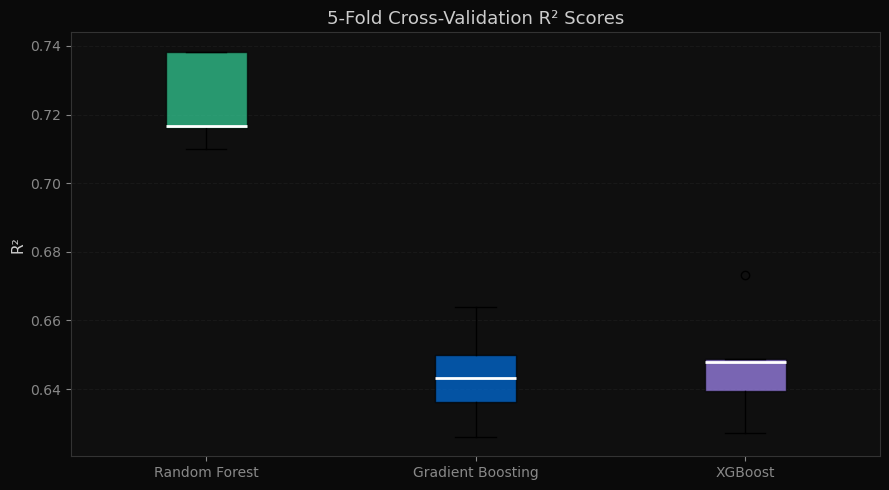

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in reg_models.items():
    scores = cross_val_score(model, X, y_reg, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: R² = {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(cv_results))
bp = ax.boxplot([v for v in cv_results.values()],
                labels=list(cv_results.keys()),
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
colors_cv = [GREEN, BLUE, PURPLE]
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('5-Fold Cross-Validation R² Scores', fontsize=13)
ax.set_ylabel('R²')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('cv_scores.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

---
## 5. Model Evaluation & Metrics

### 5.1 Regression Metrics Comparison

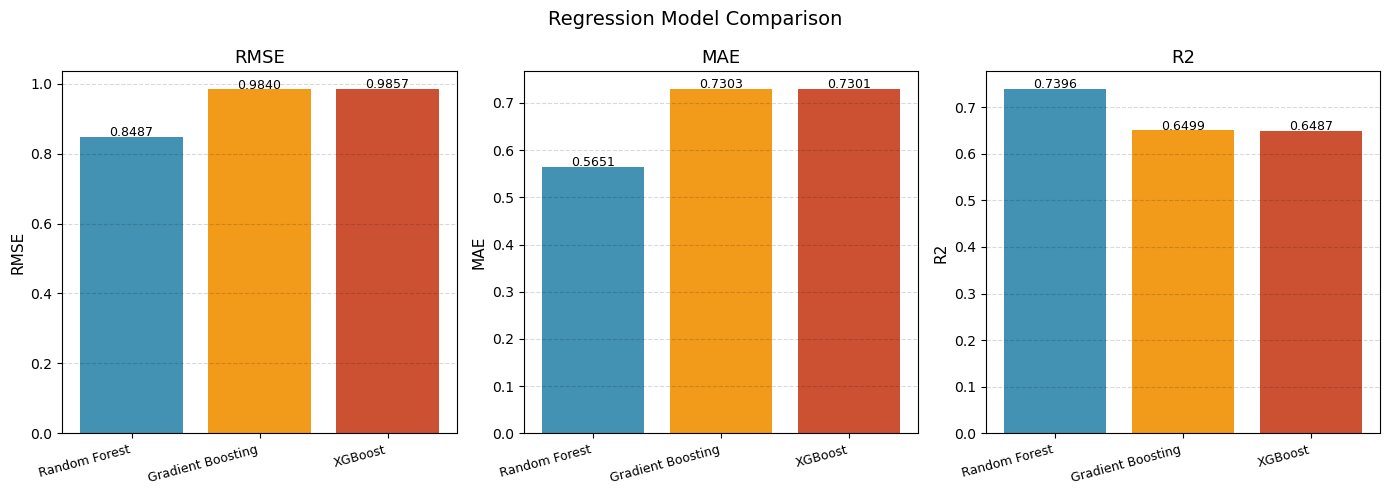

In [37]:
import matplotlib.pyplot as plt

# Global clean style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'grid.color': 'black',
    'grid.alpha': 0.15
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Regression Model Comparison', fontsize=14, color='black')

model_names = list(reg_results.keys())

# 🎨 Nice professional color palette
bar_colors = ['#2E86AB', '#F18F01', '#C73E1D', '#6A4C93', '#2A9D8F'][:len(model_names)]

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    vals = [reg_results[m][metric] for m in model_names]
    
    ax.set_facecolor('white')
    bars = ax.bar(model_names, vals, color=bar_colors, alpha=0.9)
    
    ax.set_title(metric, color='black')
    ax.set_ylabel(metric, color='black')
    
    ax.grid(True, axis='y')

    # Black axis borders
    for spine in ax.spines.values():
        spine.set_color('black')

    # Value labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}',
            ha='center',
            fontsize=9,
            color='black'
        )

    ax.tick_params(colors='black')
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(
    'eval_regression_comparison.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

### 5.2 Parity Plots (Actual vs Predicted)

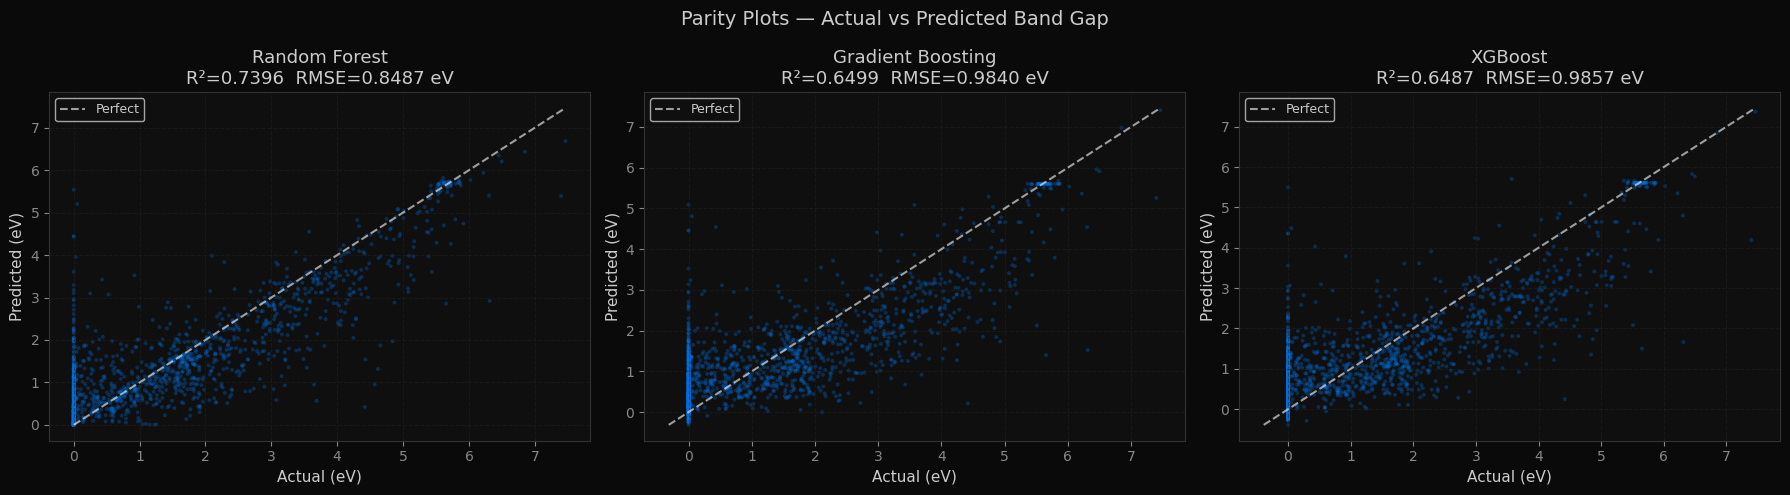

In [19]:
n_models = len(reg_results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1: axes = [axes]
fig.suptitle('Parity Plots — Actual vs Predicted Band Gap', fontsize=14)

for ax, (name, res) in zip(axes, reg_results.items()):
    ax.scatter(y_test_reg, res['predictions'], alpha=0.3, s=8,
               color=BLUE, edgecolors='none')
    lims = [min(y_test_reg.min(), res['predictions'].min()),
            max(y_test_reg.max(), res['predictions'].max())]
    ax.plot(lims, lims, '--', color='white', linewidth=1.5, alpha=0.6, label='Perfect')
    ax.set_xlabel('Actual (eV)')
    ax.set_ylabel('Predicted (eV)')
    ax.set_title(f'{name}\nR²={res["R2"]:.4f}  RMSE={res["RMSE"]:.4f} eV')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('eval_parity_plots.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 5.3 Residual Analysis

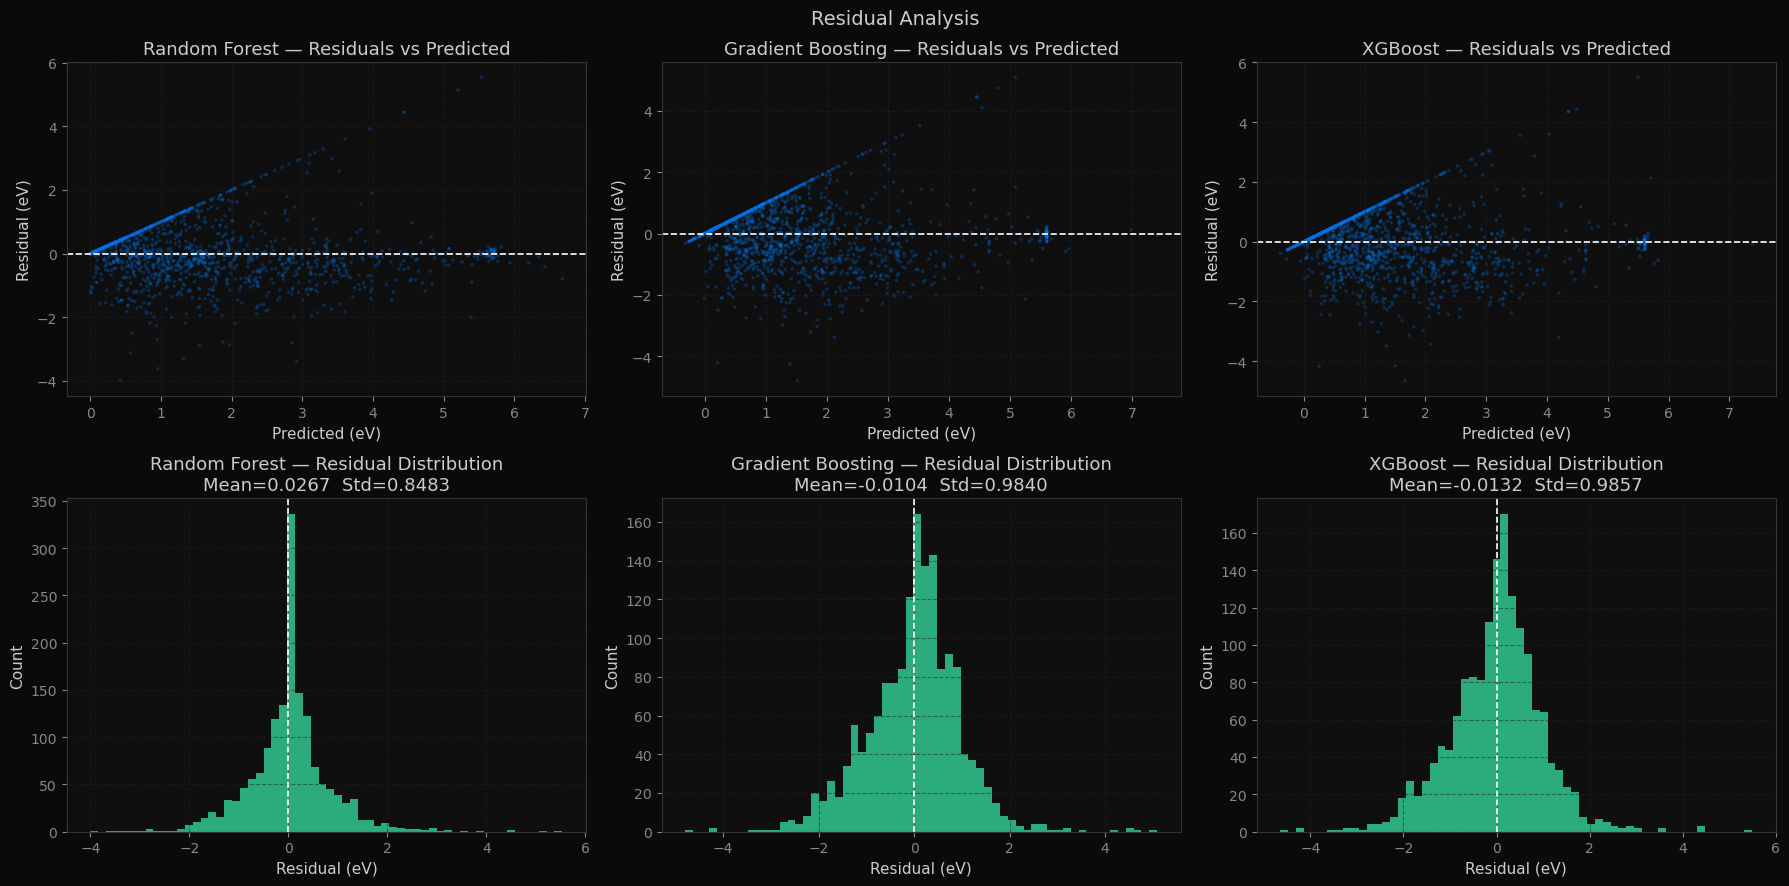

In [20]:
fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 9))
if n_models == 1: axes = axes.reshape(2, 1)
fig.suptitle('Residual Analysis', fontsize=14)

for col, (name, res) in enumerate(reg_results.items()):
    residuals = res['predictions'] - y_test_reg

    # Residuals vs predicted
    axes[0, col].scatter(res['predictions'], residuals,
                         alpha=0.3, s=6, color=BLUE, edgecolors='none')
    axes[0, col].axhline(0, color='white', linestyle='--', linewidth=1.2)
    axes[0, col].set_xlabel('Predicted (eV)')
    axes[0, col].set_ylabel('Residual (eV)')
    axes[0, col].set_title(f'{name} — Residuals vs Predicted')
    axes[0, col].grid(True)

    # Residual distribution
    axes[1, col].hist(residuals, bins=60, color=GREEN, alpha=0.8, edgecolor='none')
    axes[1, col].axvline(0, color='white', linestyle='--', linewidth=1.2)
    axes[1, col].set_xlabel('Residual (eV)')
    axes[1, col].set_ylabel('Count')
    axes[1, col].set_title(f'{name} — Residual Distribution\nMean={residuals.mean():.4f}  Std={residuals.std():.4f}')
    axes[1, col].grid(True)

plt.tight_layout()
plt.savefig('eval_residuals.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 5.4 Classification Report & Confusion Matrix


Random Forest:
              precision    recall  f1-score   support

   Non-metal       0.84      0.89      0.86       973
       Metal       0.81      0.73      0.77       626

    accuracy                           0.83      1599
   macro avg       0.82      0.81      0.81      1599
weighted avg       0.83      0.83      0.82      1599


Gradient Boosting:
              precision    recall  f1-score   support

   Non-metal       0.80      0.88      0.84       973
       Metal       0.79      0.67      0.72       626

    accuracy                           0.80      1599
   macro avg       0.80      0.78      0.78      1599
weighted avg       0.80      0.80      0.80      1599


XGBoost:
              precision    recall  f1-score   support

   Non-metal       0.80      0.89      0.84       973
       Metal       0.79      0.67      0.72       626

    accuracy                           0.80      1599
   macro avg       0.80      0.78      0.78      1599
weighted avg       0.80     

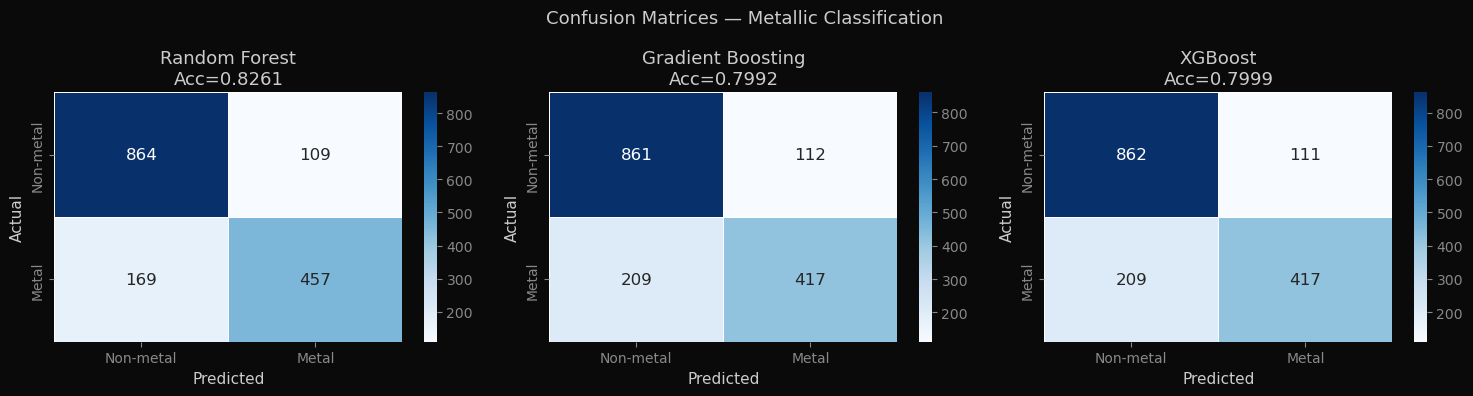

In [21]:
n_clf = len(clf_results)
fig, axes = plt.subplots(1, n_clf, figsize=(5*n_clf, 4))
if n_clf == 1: axes = [axes]
fig.suptitle('Confusion Matrices — Metallic Classification', fontsize=13)

for ax, (name, res) in zip(axes, clf_results.items()):
    cm = confusion_matrix(y_test_clf, res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Non-metal','Metal'],
                yticklabels=['Non-metal','Metal'],
                annot_kws={'size': 12})
    ax.set_title(f'{name}\nAcc={res["Accuracy"]:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    print(f'\n{name}:')
    print(classification_report(y_test_clf, res['predictions'],
                                 target_names=['Non-metal', 'Metal']))

plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

### 5.5 Feature Importance (Tree-based)

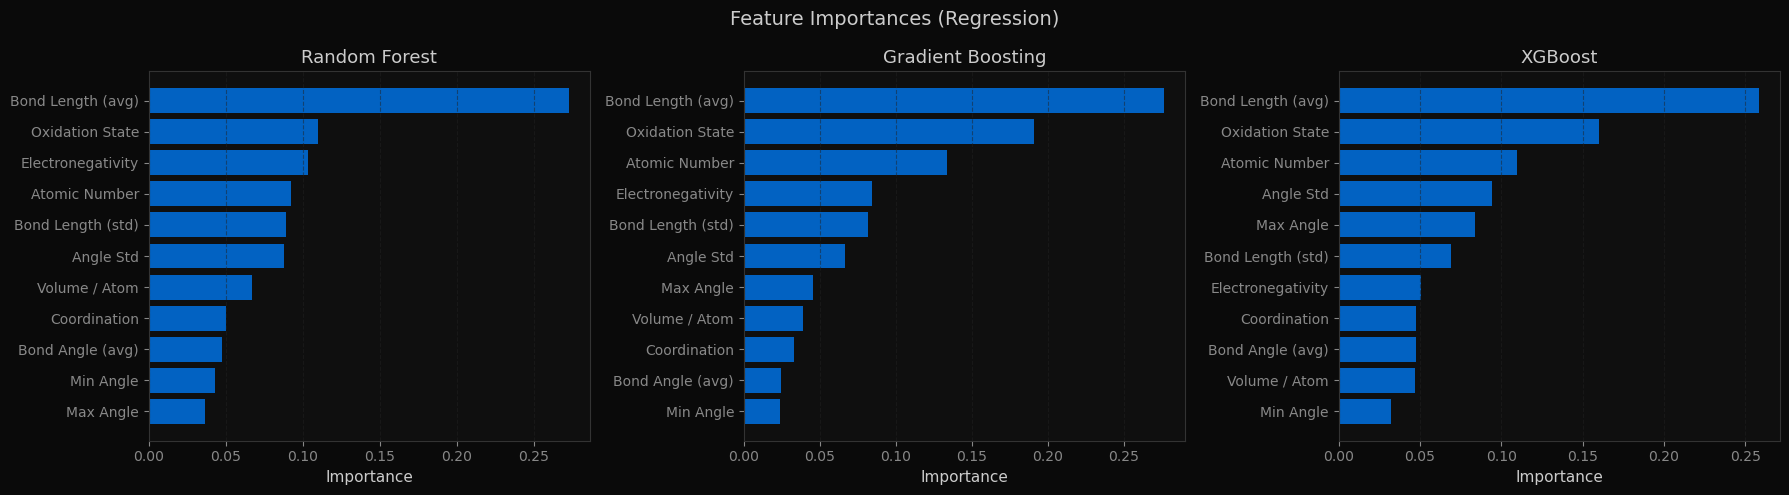

In [22]:
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1: axes = [axes]
fig.suptitle('Feature Importances (Regression)', fontsize=14)

for ax, (name, model) in zip(axes, reg_models.items()):
    importances = model.named_steps['model'].feature_importances_
    idx  = np.argsort(importances)[::-1]
    bars = ax.barh([FEATURE_NAMES[i] for i in idx[::-1]],
                   importances[idx[::-1]], color=BLUE, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('eval_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

---
## 6. SHAP Explainability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution to a specific prediction. This gives both global feature importance and per-sample explanations.

We use the **Gradient Boosting** model (the production model in Quantara).

In [23]:
# Use GB as the main model for SHAP
gb_model    = reg_models['Gradient Boosting']
X_test_imp  = gb_model.named_steps['imputer'].transform(X_test)
gb_core     = gb_model.named_steps['model']

# Subsample for speed
N_SHAP = min(500, len(X_test_imp))
rng    = np.random.default_rng(42)
idx    = rng.choice(len(X_test_imp), N_SHAP, replace=False)
X_shap = X_test_imp[idx]

explainer   = shap.TreeExplainer(gb_core)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed for {N_SHAP} samples.')
print(f'SHAP matrix shape: {shap_values.shape}')

SHAP values computed for 500 samples.
SHAP matrix shape: (500, 11)


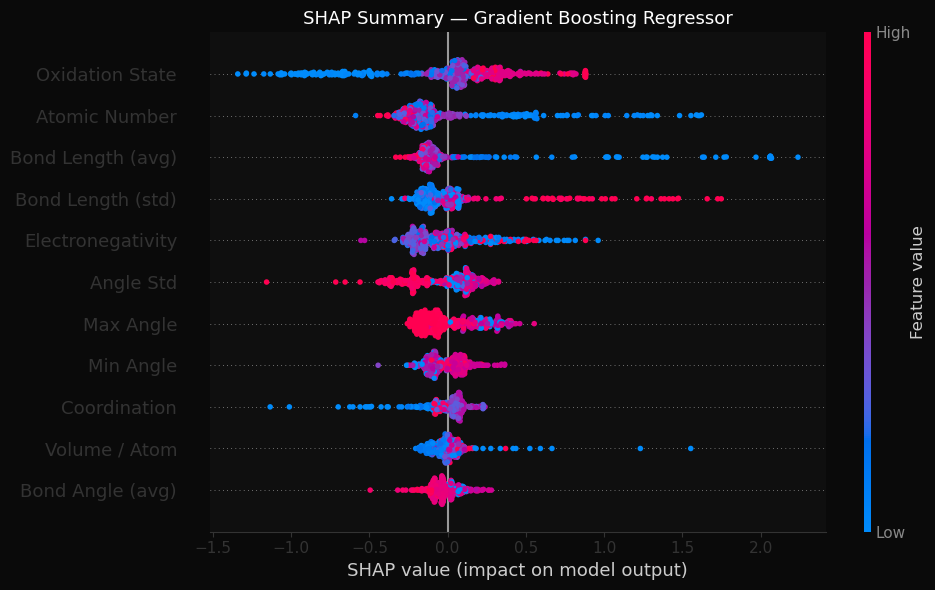

In [24]:
# Global SHAP summary — beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap,
                  feature_names=FEATURE_NAMES,
                  show=False, plot_size=None)
plt.title('SHAP Summary — Gradient Boosting Regressor', fontsize=13, color='white')
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

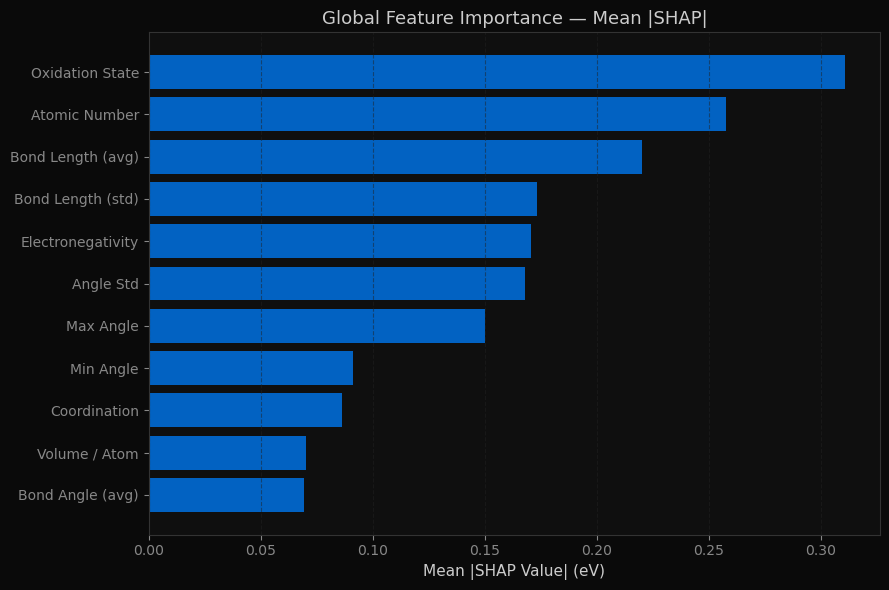

In [25]:
# SHAP bar plot — mean absolute importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
idx_sorted    = np.argsort(mean_abs_shap)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([FEATURE_NAMES[i] for i in idx_sorted],
        mean_abs_shap[idx_sorted], color=BLUE, alpha=0.85)
ax.set_xlabel('Mean |SHAP Value| (eV)')
ax.set_title('Global Feature Importance — Mean |SHAP|', fontsize=13)
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

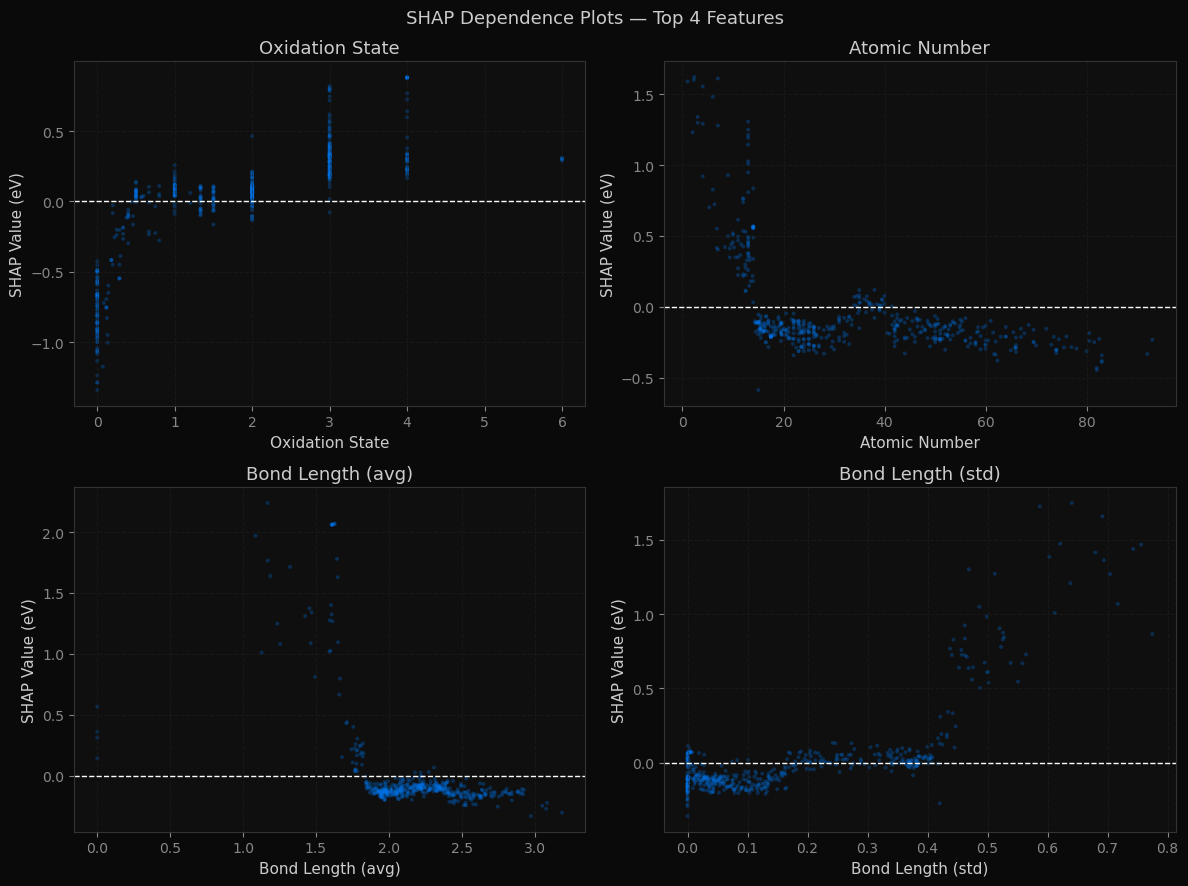

In [26]:
# SHAP dependence plots for top 4 features
top4 = np.argsort(mean_abs_shap)[::-1][:4]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13)

for ax, feat_idx in zip(axes.flatten(), top4):
    ax.scatter(X_shap[:, feat_idx], shap_values[:, feat_idx],
               alpha=0.3, s=8, color=BLUE, edgecolors='none')
    ax.axhline(0, color='white', linestyle='--', linewidth=1)
    ax.set_xlabel(FEATURE_NAMES[feat_idx])
    ax.set_ylabel('SHAP Value (eV)')
    ax.set_title(FEATURE_NAMES[feat_idx])
    ax.grid(True)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

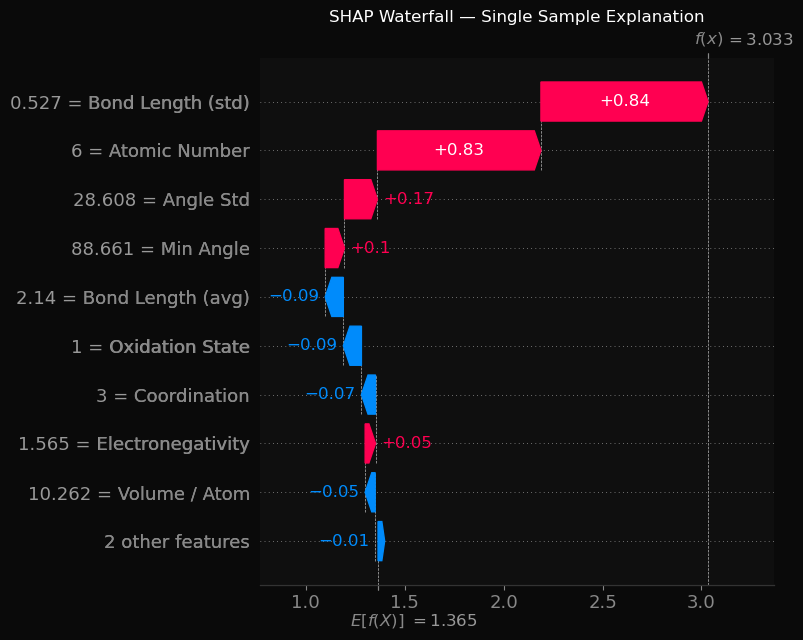

In [27]:
# Single-sample waterfall explanation
sample_idx = 0
shap_exp = shap.Explanation(
    values         = shap_values[sample_idx],
    base_values    = explainer.expected_value,
    data           = X_shap[sample_idx],
    feature_names  = FEATURE_NAMES
)
plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_exp, show=False)
plt.title('SHAP Waterfall — Single Sample Explanation', fontsize=12, color='white')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

---
## 7. Confidence Intervals — Quantile Regression

We train two additional Gradient Boosting models at the 10th and 90th percentile quantiles to produce **80% prediction intervals** for each sample.

In [28]:
base_params = dict(n_estimators=100, learning_rate=0.05,
                   subsample=0.8, random_state=42, max_depth=3)

q_low = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model',   GradientBoostingRegressor(loss='quantile', alpha=0.10, **base_params))
])
q_high = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model',   GradientBoostingRegressor(loss='quantile', alpha=0.90, **base_params))
])

print('Training quantile models...')
q_low.fit(X_train,  y_train_reg)
q_high.fit(X_train, y_train_reg)

y_low  = q_low.predict(X_test)
y_high = q_high.predict(X_test)
y_pred = reg_models['Gradient Boosting'].predict(X_test)

# Coverage
coverage = np.mean((y_test_reg >= y_low) & (y_test_reg <= y_high))
avg_width = np.mean(y_high - y_low)
print(f'80% CI Coverage : {coverage*100:.1f}% (target: 80%)')
print(f'Average CI width: {avg_width:.4f} eV')

Training quantile models...
80% CI Coverage : 89.6% (target: 80%)
Average CI width: 2.8801 eV


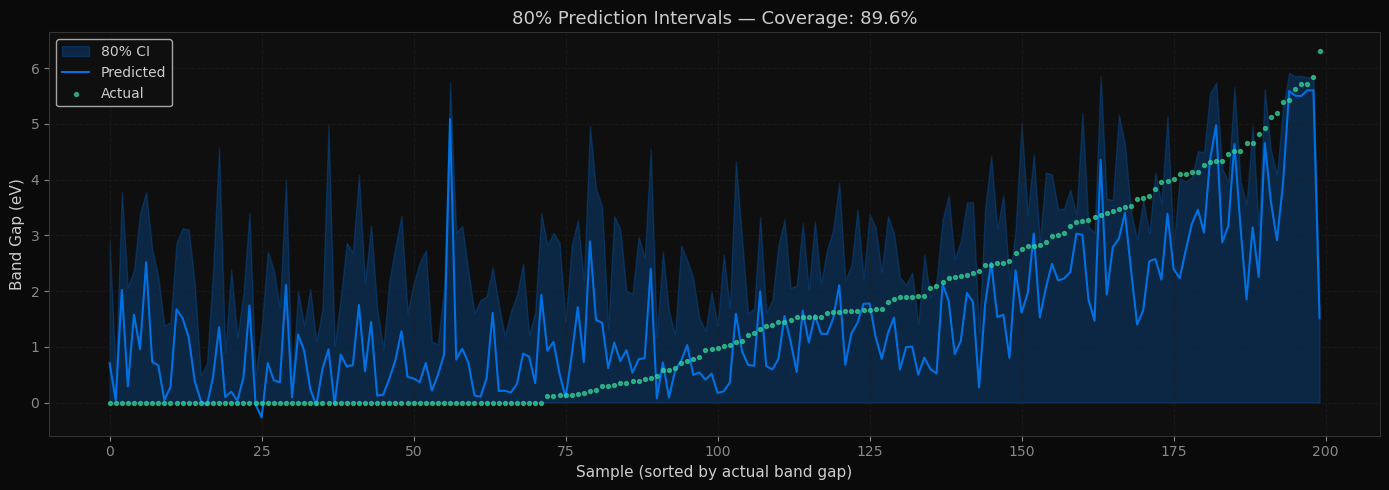

In [29]:
# Plot CI on a sample of 200 test points
n_show = 200
sort_idx = np.argsort(y_test_reg[:n_show])
x_axis   = np.arange(n_show)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(x_axis, y_low[:n_show][sort_idx], y_high[:n_show][sort_idx],
                alpha=0.25, color=BLUE, label='80% CI')
ax.plot(x_axis, y_pred[:n_show][sort_idx], color=BLUE, linewidth=1.5, label='Predicted')
ax.scatter(x_axis, y_test_reg[:n_show][sort_idx],
           color=GREEN, s=8, alpha=0.7, zorder=5, label='Actual')
ax.set_xlabel('Sample (sorted by actual band gap)')
ax.set_ylabel('Band Gap (eV)')
ax.set_title(f'80% Prediction Intervals — Coverage: {coverage*100:.1f}%', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

---
## 8. PCA — Materials Property Space

Principal Component Analysis reduces the 11-dimensional feature space to 2D for visualisation. Points that cluster together have similar structural and chemical environments.

In [30]:
# PCA on full dataset (sampled for speed)
MAX_PCA = 3000
rng_pca = np.random.default_rng(42)
pca_idx = np.sort(rng_pca.choice(len(X), min(MAX_PCA, len(X)), replace=False))

X_pca_raw = X[pca_idx]
col_means = np.nanmean(X_pca_raw, axis=0)
col_means = np.where(np.isnan(col_means), 0, col_means)
X_filled  = np.where(np.isnan(X_pca_raw), col_means, X_pca_raw)

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_filled)
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_sc)

pca_bg    = reg_models['Gradient Boosting'].predict(X_pca_raw).astype(float)
pca_metal = clf_models['Gradient Boosting'].predict(X_pca_raw).astype(bool)
pca_type  = np.array(['Metal' if m else ('Semiconductor' if bg < 3.0 else 'Insulator')
                       for m, bg in zip(pca_metal, pca_bg)])

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

Variance explained: PC1=34.0%  PC2=20.5%


In [38]:
pca_full = PCA()
pca_full.fit(X_sc)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

In [39]:
for i, val in enumerate(cumulative):
    print(f"PC{i+1}: {val*100:.2f}%")

PC1: 33.99%
PC2: 54.51%
PC3: 67.40%
PC4: 76.67%
PC5: 84.12%
PC6: 89.72%
PC7: 94.45%
PC8: 97.53%
PC9: 99.54%
PC10: 99.83%
PC11: 100.00%


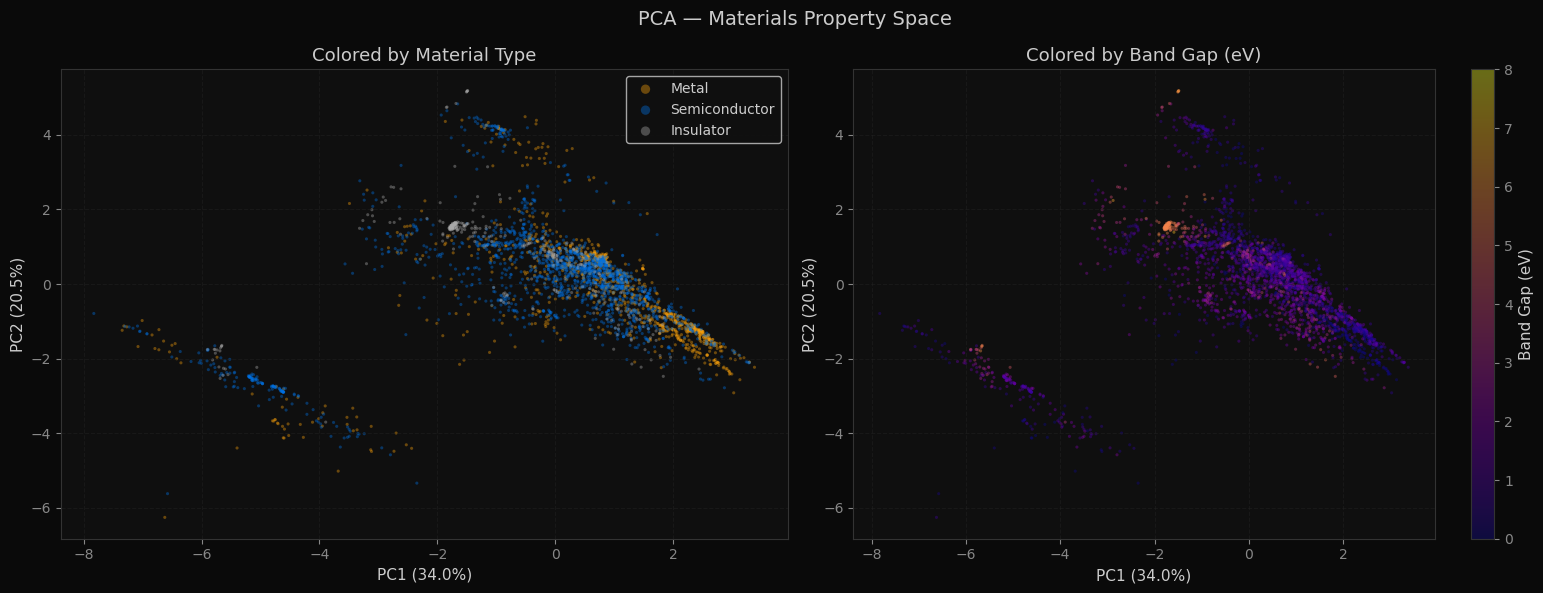

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA — Materials Property Space', fontsize=14)

# Colored by material type
type_color_map = {'Metal': AMBER, 'Semiconductor': BLUE, 'Insulator': '#aaaaaa'}
for mtype, color in type_color_map.items():
    mask = pca_type == mtype
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    c=color, s=5, alpha=0.4, edgecolors='none', label=mtype)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Colored by Material Type')
axes[0].legend(markerscale=3, fontsize=10)
axes[0].grid(True)

# Colored by band gap value
sc = axes[1].scatter(coords[:, 0], coords[:, 1],
                     c=pca_bg, cmap='plasma', s=5,
                     alpha=0.4, edgecolors='none', vmin=0, vmax=8)
plt.colorbar(sc, ax=axes[1], label='Band Gap (eV)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Colored by Band Gap (eV)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('pca_property_space.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

PCA Loadings:
                      PC1     PC2
Max Angle          0.4449  0.2924
Angle Std          0.4052 -0.0806
Coordination       0.3682 -0.2314
Bond Length (avg)  0.3559 -0.2555
Electronegativity -0.3439  0.1494
Bond Angle (avg)   0.2885  0.5253
Bond Length (std)  0.2548 -0.2167
Atomic Number      0.2303 -0.2507
Oxidation State    0.1801  0.0830
Volume / Atom     -0.1162 -0.1380
Min Angle          0.1015  0.5960


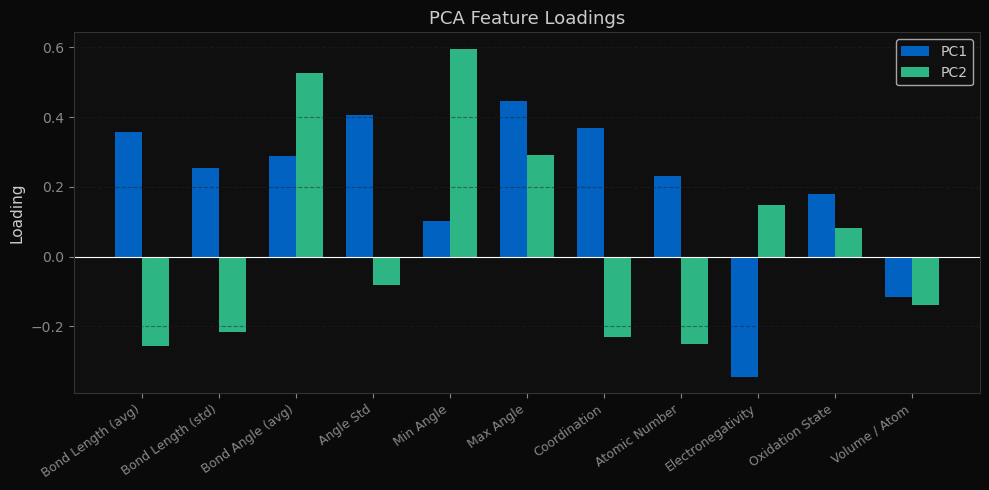

In [32]:
# PCA loadings — which features drive PC1 and PC2?
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_NAMES,
    columns=['PC1', 'PC2']
).round(4)
print('PCA Loadings:')
print(loadings.sort_values('PC1', key=abs, ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(FEATURE_NAMES))
width = 0.35
ax.bar(x_pos - width/2, loadings['PC1'], width, label='PC1', color=BLUE, alpha=0.85)
ax.bar(x_pos + width/2, loadings['PC2'], width, label='PC2', color=GREEN, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURE_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Loading')
ax.set_title('PCA Feature Loadings', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(0, color='white', linewidth=0.8)
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

---
## 9. Final Model Summary

In [33]:
print('=' * 55)
print('  QUANTARA — FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print()
print('REGRESSION (Band Gap Prediction)')
print('-' * 55)
for name, res in reg_results.items():
    print(f'  {name:<22}  RMSE={res["RMSE"]:.4f}  MAE={res["MAE"]:.4f}  R²={res["R2"]:.4f}')

print()
print('CLASSIFICATION (Metallic vs Non-metallic)')
print('-' * 55)
for name, res in clf_results.items():
    print(f'  {name:<22}  Accuracy={res["Accuracy"]:.4f}')

print()
print('CONFIDENCE INTERVALS (80% Quantile Regression)')
print('-' * 55)
print(f'  Coverage : {coverage*100:.1f}%  (target 80%)')
print(f'  Avg width: {avg_width:.4f} eV')

print()
print('PCA')
print('-' * 55)
print(f'  PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2 variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total (2 components)  : {sum(pca.explained_variance_ratio_)*100:.1f}%')
print('=' * 55)

  QUANTARA — FINAL MODEL PERFORMANCE SUMMARY

REGRESSION (Band Gap Prediction)
-------------------------------------------------------
  Random Forest           RMSE=0.8487  MAE=0.5651  R²=0.7396
  Gradient Boosting       RMSE=0.9840  MAE=0.7303  R²=0.6499
  XGBoost                 RMSE=0.9857  MAE=0.7301  R²=0.6487

CLASSIFICATION (Metallic vs Non-metallic)
-------------------------------------------------------
  Random Forest           Accuracy=0.8261
  Gradient Boosting       Accuracy=0.7992
  XGBoost                 Accuracy=0.7999

CONFIDENCE INTERVALS (80% Quantile Regression)
-------------------------------------------------------
  Coverage : 89.6%  (target 80%)
  Avg width: 2.8801 eV

PCA
-------------------------------------------------------
  PC1 variance explained: 34.0%
  PC2 variance explained: 20.5%
  Total (2 components)  : 54.5%
